# 04 - Analyse des genres et catégories

## Objectif

Cette analyse étudie les catégories associées aux contenus.

La colonne `listed_in` contient plusieurs catégories pour chaque contenu. Elle peut regrouper des genres mais également des catégories spécifiques aux films ou aux séries.

Nous allons donc analyser leur fréquence et comparer leur répartition selon le type de contenu.


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Chargement des données

In [2]:
df = pd.read_csv("../data/processed/netflix_titles_clean.csv")

print(f"Nombre de contenus : {len(df)}")


Nombre de contenus : 8807


## 3. Exploration des catégories

In [3]:
df["listed_in"].head(10)


0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
5                   TV Dramas, TV Horror, TV Mysteries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
9                                     Comedies, Dramas
Name: listed_in, dtype: str

## 4. Séparation des catégories

In [4]:
categories = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
)

categories.head(20)


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64

## 5. Nombre de catégories différentes

In [5]:
print(f"Nombre de catégories différentes : {categories.shape[0]}")


Nombre de catégories différentes : 42


## 6. Top 15 des catégories

In [6]:
top_categories = categories.head(15)

top_categories


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

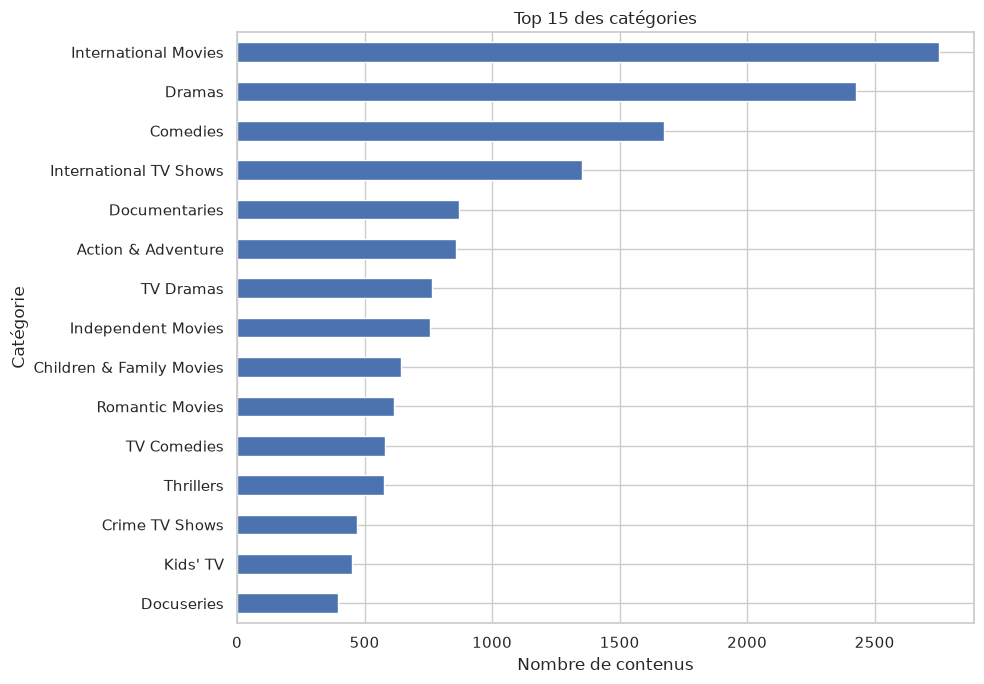

In [7]:
plt.figure(figsize=(10, 7))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 15 des catégories")
plt.xlabel("Nombre de contenus")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()


## 7. Catégories selon le type de contenu

In [8]:
df_categories = df.assign(
    category=df["listed_in"].str.split(", ")
).explode("category")

category_by_type = (
    df_categories
    .groupby(["category", "type"])
    .size()
    .unstack(fill_value=0)
)

category_by_type.head(20)


type,Movie,TV Show
category,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,641,0
Classic & Cult TV,0,28
Classic Movies,116,0
Comedies,1674,0
Crime TV Shows,0,470


## 8. Catégories les plus représentées pour les films

In [9]:
movie_categories = (
    df_categories[df_categories["type"] == "Movie"]["category"]
    .value_counts()
)

movie_categories.head(15)


category
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Horror Movies                357
Stand-Up Comedy              343
Sci-Fi & Fantasy             243
Sports Movies                219
Classic Movies               116
Name: count, dtype: int64

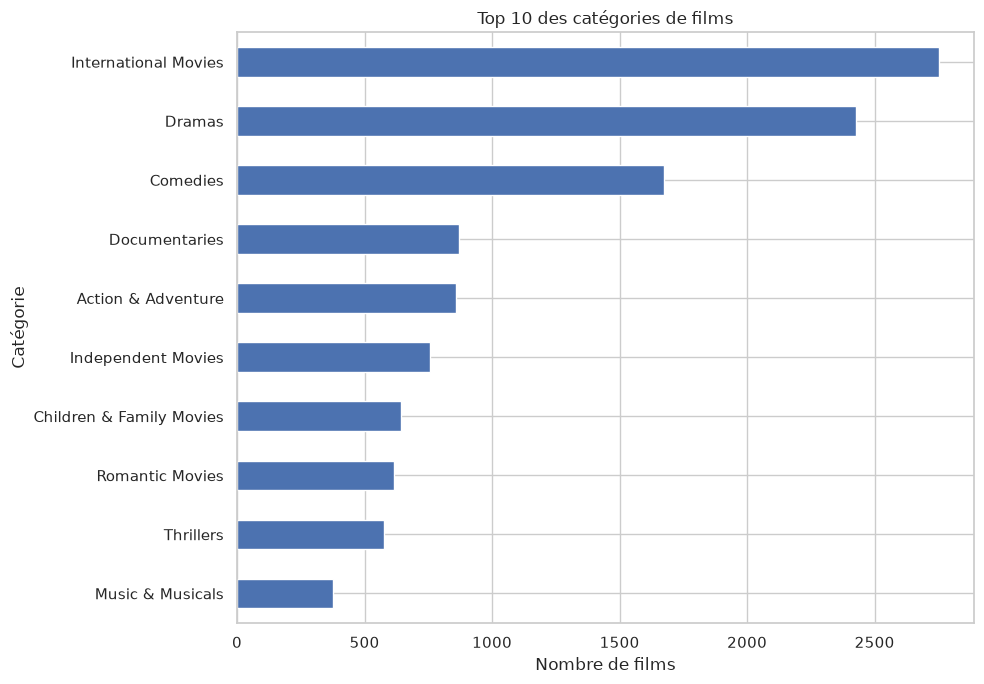

In [10]:
plt.figure(figsize=(10, 7))

movie_categories.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des catégories de films")
plt.xlabel("Nombre de films")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()


## 9. Catégories les plus représentées pour les séries

In [11]:
show_categories = (
    df_categories[df_categories["type"] == "TV Show"]["category"]
    .value_counts()
)

show_categories.head(15)


category
International TV Shows       1351
TV Dramas                     763
TV Comedies                   581
Crime TV Shows                470
Kids' TV                      451
Docuseries                    395
Romantic TV Shows             370
Reality TV                    255
British TV Shows              253
Anime Series                  176
Spanish-Language TV Shows     174
TV Action & Adventure         168
Korean TV Shows               151
TV Mysteries                   98
Science & Nature TV            92
Name: count, dtype: int64

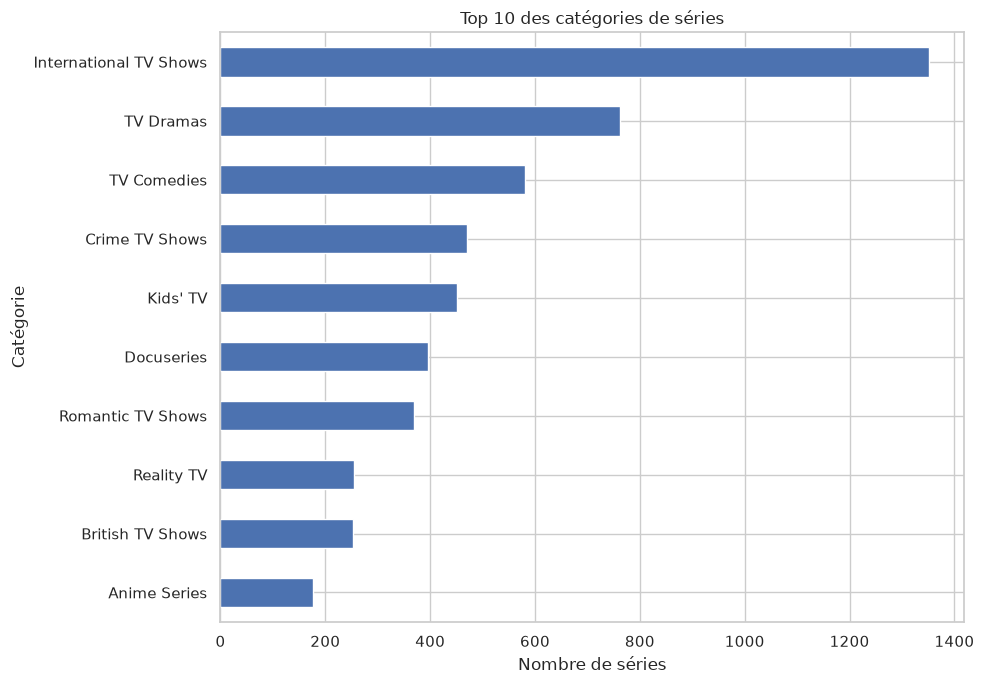

In [12]:
plt.figure(figsize=(10, 7))

show_categories.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des catégories de séries")
plt.xlabel("Nombre de séries")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()


## 10. Comparaison Films / Séries

In [13]:
comparison = (
    category_by_type
    .copy()
)

comparison["Total"] = comparison.sum(axis=1)

comparison.sort_values("Total", ascending=False).head(15)


type,Movie,TV Show,Total
category,,,
International Movies,2752,0,2752
Dramas,2427,0,2427
Comedies,1674,0,1674
International TV Shows,0,1351,1351
Documentaries,869,0,869
Action & Adventure,859,0,859
TV Dramas,0,763,763
Independent Movies,756,0,756
Children & Family Movies,641,0,641


## 11. Nombre moyen de catégories par contenu

In [14]:
categories_per_content = (
    df["listed_in"]
    .str.split(", ")
    .str.len()
)

print(
    f"Nombre moyen de catégories par contenu : "
    f"{categories_per_content.mean():.2f}"
)

print(
    f"Nombre maximum de catégories pour un contenu : "
    f"{categories_per_content.max()}"
)


Nombre moyen de catégories par contenu : 2.19
Nombre maximum de catégories pour un contenu : 3


## 12. Observation importante

### Interprétation

La colonne `listed_in` ne contient pas uniquement des genres au sens strict.

On retrouve également des catégories comme :

- `International Movies`
- `International TV Shows`
- `TV Dramas`
- `TV Comedies`
- `Kids' TV`

Il est donc plus précis de parler de **catégories** plutôt que de considérer toutes les valeurs comme des genres purs.

Cette distinction permet d'éviter une interprétation incorrecte des résultats.


## 13. Conclusion

L'analyse montre les catégories les plus représentées dans le catalogue et permet de comparer leur présence entre les films et les séries.

La colonne `listed_in` fournit une vision riche du contenu mais mélange plusieurs types de catégorisation. Cette particularité devra être prise en compte dans les analyses suivantes.
